<a href="https://colab.research.google.com/github/Kristina-Analyst/Portfolio-Projects/blob/main/Portfolio_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Проєкт для портфоліо
### Аналіз трафіку та продажів
Мета цього проєкту — дослідити розподіл сесій та покупок у різних регіонах і за різними маркетинговими каналами. Використано описову статистику, перевірку нормальності, ANOVA, тест Крускала-Уолліса та кореляційний аналіз.

* Дискриптивна статистика
* Аналіз диманіки продажів
* Статистичний аналіз відмінностей між групами
* Статистичний аналіз взаємозвʼязків
* Лінійна регрессія

In [ ]:
from google.colab import auth
from google.cloud import bigquery
import pandas as pd
import numpy as np
auth.authenticate_user()
client = bigquery.Client(project="data-analytics-mate")
query ="""
SELECT
s.date as order_date,
s.ga_session_id,
sp.continent,
sp.country,
sp.device,
sp.browser,
sp.mobile_model_name,
sp.operating_system,
sp.language,
sp.medium,
sp.channel,
acs.account_id,
acc.is_verified,
acc.is_unsubscribed,
p.category,
p.name,
p.price,
p.short_description
FROM
`DA.session` s
JOIN `DA.session_params` sp ON s.ga_session_id = sp.ga_session_id
LEFT JOIN `DA.account_session` acs ON s.ga_session_id = acs.ga_session_id
LEFT JOIN `DA.account` acc ON acs.account_id = acc.id
LEFT JOIN `DA.order` o ON s.ga_session_id = o.ga_session_id
LEFT JOIN `DA.product` p ON o.item_id = p.item_id
"""
df = client.query(query).to_dataframe()
df['verified_status'] = df['is_verified'].map({1: 'verified', 0: 'not_verified'}).fillna('unknown')
df['unsubscribed_status'] = df['is_unsubscribed'].map({1: 'unsubscribed', 0: 'not_unsubscribed'}).fillna('unknown')
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")
df.head()

,order_date,ga_session_id,continent,country,device,browser,mobile_model_name,operating_system,language,medium,channel,account_id,is_verified,is_unsubscribed,category,name,price,short_description,verified_status,unsubscribed_status
0,2021-01-19,7268004754,(not set),(not set),desktop,Chrome,Chrome,Web,en-gb,(none),Direct,<NA>,<NA>,<NA>,None,None,NaN,None,unknown,unknown
1,2021-01-06,8321293308,(not set),(not set),desktop,Chrome,Chrome,Web,None,(none),Direct,<NA>,<NA>,<NA>,None,None,NaN,None,unknown,unknown
2,2020-11-05,4392362373,(not set),(not set),desktop,Chrome,Chrome,Web,None,organic,Organic Search,<NA>,<NA>,<NA>,None,None,NaN,None,unknown,unknown
3,2020-12-09,140108698,(not set),(not set),desktop,Chrome,Safari,Web,en-us,(none),Direct,<NA>,<NA>,<NA>,None,None,NaN,None,unknown,unknown
4,2020-11-10,8351127264,(not set),(not set),mobile,Safari,iPhone,Web,en-us,organic,Organic Search,<NA>,<NA>,<NA>,None,None,NaN,None,unknown,unknown


Загальна інформація

In [ ]:
df.info()
print("\nStart: ",np.min(df["order_date"]))
print("Stop: ",np.max(df["order_date"]))

<class 'pandas.core.frame.DataFrame'>
Index: 33538 entries, 12 to 349509
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   order_date           33538 non-null  datetime64[ns]
 1   ga_session_id        33538 non-null  Int64         
 2   continent            33538 non-null  object        
 3   country              33538 non-null  object        
 4   device               33538 non-null  object        
 5   browser              33538 non-null  object        
 6   mobile_model_name    33538 non-null  object        
 7   operating_system     33538 non-null  object        
 8   language             22531 non-null  object        
 9   medium               33538 non-null  object        
 10  channel              33538 non-null  object        
 11  account_id           2781 non-null   Int64         
 12  is_verified          2781 non-null   Int64         
 13  is_unsubscribed      2781 non-null

# Дискриптивна статистика: Кількість замовлень


*   **Верифіковані** аккаунти **1989**, що набагато більше ніж **не верифікованих 792.**
*   **Відписок 447**, що набагото менше ніж тих, хто **не відписався 2334**.
* Топ три **кращих** категорій по продажам: **"Bookcases & shelving units", "Chairs", "Sofas & armchairs"**. Топ три **найгірші** категорії:**"Room dividers", "Sideboards, buffets & console tables", "Cafe furniture".**
* Топ три **кращих** країн по кількості продажів: **USA, India, Canada**. Топ три **найгірших** країн по кількості продажів: **Luxemburg, Bahams, Bosnia & Herzegovina**.
* **Найкращий** континет по кількості продажів - **Americas**. **Найгірший** континент по кількості продажів - **Africa**.
* **Найкращий** по кількості продажів браузер - **Chrome**. **Найгірший** по кількості продажів браузер  - **Android webview**.
* **Найкращий** канал по по кількості продажів - **Organic**. **Найгірший** канал по по кількості продажів - **Social search**.
* **Найкраща** операційна система по продажам - **Web**. **Найгірша** операційна система по по кількості продажів - **Macintosh**.



In [ ]:
verified_count = df['verified_status'].isin(['verified']).sum()
print(f"\nVerified count: {verified_count}")
not_verified_count = df['verified_status'].isin(['not_verified']).sum()
print(f"Not verified count: {not_verified_count}")
unsubscribed = df['unsubscribed_status'].isin(['unsubscribed']).sum()
print(f"Unsubscribed: {unsubscribed}")
not_unsubscribed = df['unsubscribed_status'].isin(['not_unsubscribed']).sum()
print(f"Not unsubscribed: {not_unsubscribed}")
print(f"\nCount of category: ", df["category"].value_counts())
print(f"\nCountry: ", df["country"].value_counts())
print(f"\nContinent: ", df["continent"].value_counts())
print(f"\nChannel: ", df["channel"].value_counts())
print(f"\nBrowser: ", df["browser"].value_counts())
print(f"\nOperating system: ", df["operating_system"].value_counts())


Verified count: 1989
Not verified count: 792
Unsubscribed: 447
Not unsubscribed: 2334

Count of category:  category
Bookcases & shelving units              7630
Chairs                                  5952
Sofas & armchairs                       4301
Tables & desks                          2941
Beds                                    2926
Cabinets & cupboards                    2318
Outdoor furniture                       2229
Children's furniture                    1702
Chests of drawers & drawer units        1452
Bar furniture                           1092
Nursery furniture                        394
Café furniture                           359
Sideboards, buffets & console tables     132
Room dividers                            110
Name: count, dtype: int64

Country:  country
United States           14673
India                    3029
Canada                   2560
United Kingdom           1029
France                    678
                        ...  
Bahrain                     

# Дискриптивна статистика: Сума продажів (Візуалізація)
* Є різниця сумми з кількістю. Тут топ три **найкращі** категорії по суммі продажів це: **"Sofas & armchairs", "Chairs", "Beds"**. Топ 3 **найгірших** категорій по суммі продажів: **"Room dividers", "Sideboards, buffets & console tabels", "Cafes furniture"**.
* **Найкращий** канал по суммі продажів **Organic**. **Найгірший** канал по суммі продажів **Social Search**. (як і по кількості продажів)
* По країнам по суммі продажів *все так само як і по кількості*.
* По верифікованим аккаунтам *все так само*. У верифікованих аккаунтів сумма продажів значно більша ніж у неверифікаваних.

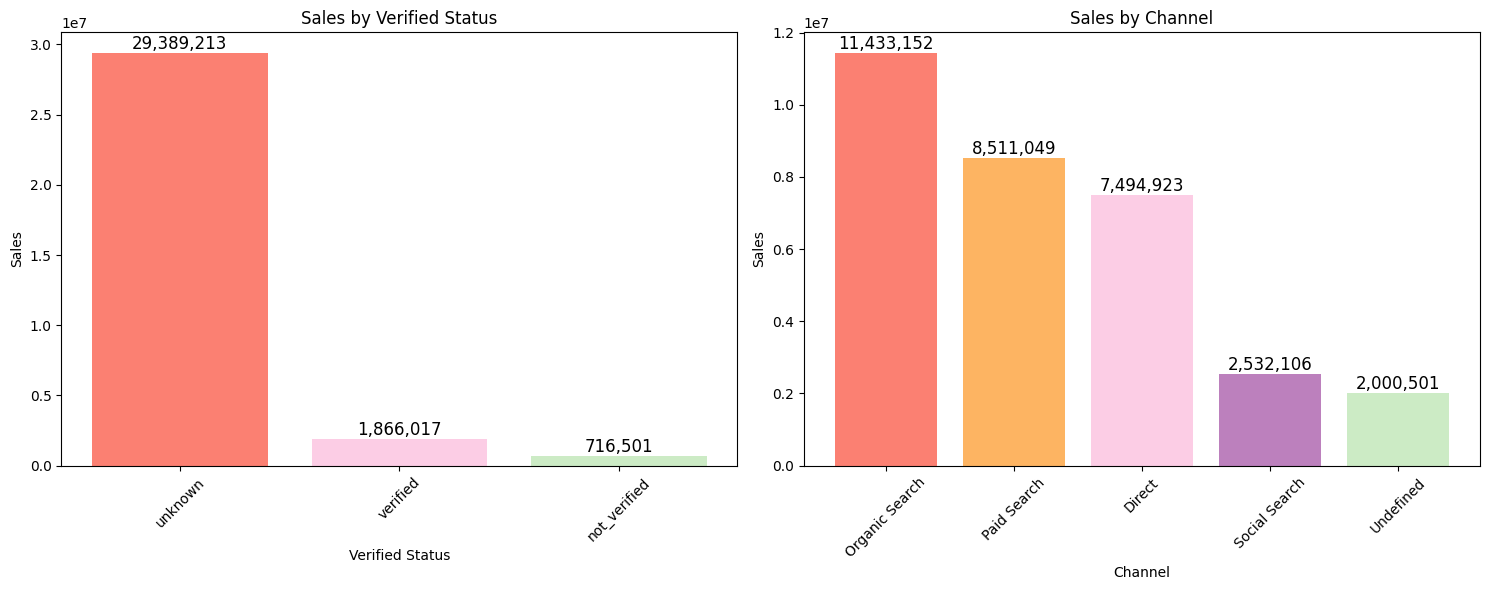

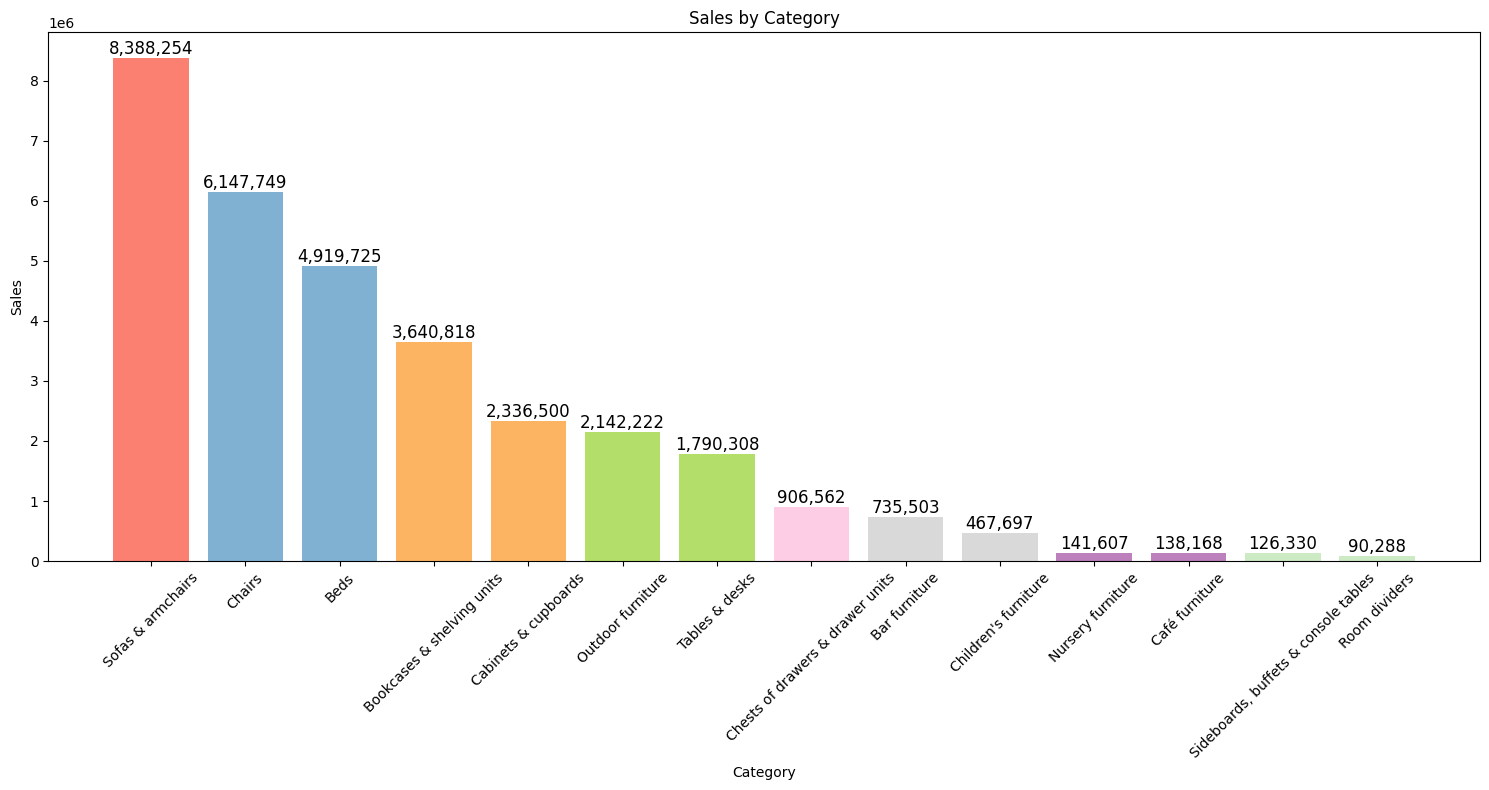



Total sales by country:  country
United States           13943553.9
India                    2809762.0
Canada                   2437921.0
United Kingdom            938317.9
France                    710692.8
                           ...    
Bahamas                     2411.0
Guatemala                   2259.0
Ghana                       1018.0
Bosnia & Herzegovina         939.0
Luxembourg                   879.0
Name: price, Length: 108, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.animation import FuncAnimation

category_group = df.groupby("category")["price"].sum().sort_values(ascending = False)
channel_group = df.groupby("channel")["price"].sum().sort_values(ascending = False)
country_group = df.groupby("country")["price"].sum().sort_values(ascending = False)
verified_group = df.groupby("verified_status")["price"].sum().sort_values(ascending = False)

fig, ax = plt.subplots(1, 2, figsize=(15, 6))
colors = plt.cm.Set3(np.linspace(0.3, 0.9, len(verified_group)))
bars0 = ax[0].bar(verified_group.index, verified_group.values, color = colors)
ax[0].set_title("Sales by Verified Status", )
ax[0].set_xlabel("Verified Status")
ax[0].set_ylabel("Sales")
for bar in bars0:
    ax[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() - 40,
        f"{bar.get_height():,.0f}",
        ha="center",
        va="bottom",
        color="black",
        fontsize=12
    )
ax[0].tick_params(axis='x', rotation=45)

colors1 = plt.cm.Set3(np.linspace(0.3, 0.9, len(channel_group)))
bars1 = ax[1].bar(channel_group.index, channel_group.values, color = colors1)
ax[1].set_title("Sales by Channel")
ax[1].set_xlabel("Channel")
ax[1].set_ylabel("Sales")
for bar in bars1:
    ax[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() - 40,
        f"{bar.get_height():,.0f}",
        ha="center",
        va="bottom",
        color="black",
        fontsize=12
    )
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

colors2 = plt.cm.Set3(np.linspace(0.3, 0.9, len(category_group)))
plt.figure(figsize=(15, 8))
bars2 = plt.bar(category_group.index, category_group.values, color = colors2)
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
for bar in bars2:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() - 40,
        f"{bar.get_height():,.0f}",
        ha="center",
        va="bottom",
        color="black",
        fontsize=12
    )
plt.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()
print("\n\nTotal sales by country: ", country_group)


* Викидів достатньо багато.
* Середнє значення приблизно у два рази більше медіани, можна зробити висновок, що менших чисел більше ніж великих.

In [ ]:
q1 = np.percentile(df["price"], 25)
q3 = np.percentile(df["price"], 75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
outliers = [x for x in df["price"] if x < lower or x > upper]
avg_price = df["price"].mean()
median_price = df["price"].median()
print("Outliers count: ", len(outliers))
print("\nAverage price: ", avg_price)
print("Median price: ", median_price)

Outliers count:  2826

Average price:  953.298679110263
Median price:  445.0


* Топ-10 категорій товарів у країні з найбільшою суммою продажів(USA).
* В яких країнах найбільше зареєстрованих користувачів?
* Зведена таблиця по загальни продажам за категоріями товарів (топ-10 категорій) у різних країнах (топ-5 країн)

In [ ]:
usa_sales = df[df["country"].str.contains("United States", na=False)]
pivot = pd.pivot_table(usa_sales, values="price", index="category", aggfunc="sum").sort_values(by = "price",ascending = False).head(10)
print(pivot)
verified = df[df["verified_status"].str.contains("verified", na = False)]
pivot2 = pd.pivot_table(verified, values = "verified_status", index = "country", aggfunc="count").sort_values(by = "verified_status",ascending = False)
print(pivot2)
top_countries = df.groupby("country")["price"].sum().nlargest(5).index
top_categories = df.groupby("category")["price"].sum().nlargest(10).index
filtered_df = df[df["country"].isin(top_countries) & df["category"].isin(top_categories)]
pivot_table = pd.pivot_table(filtered_df, values="price", index="category", columns="country", aggfunc="sum", fill_value=0)
pivot_table["Total"] = pivot_table.sum(axis=1)
pivot_table = pivot_table.sort_values("Total", ascending=False).drop(columns="Total")
print("Pivot table by total sales(Top-10 categories, Top-5 country):")
display(pivot_table)


                                      price
category                                   
Sofas & armchairs                 3707144.5
Chairs                            2619773.8
Beds                              2213058.0
Bookcases & shelving units        1567606.9
Cabinets & cupboards               994545.5
Outdoor furniture                  929245.2
Tables & desks                     777865.0
Chests of drawers & drawer units   382388.0
Bar furniture                      330805.0
Children's furniture               207575.0
                verified_status
country                        
United States              1207
India                       246
Canada                      207
United Kingdom               88
France                       56
...                         ...
Kuwait                        1
Jordan                        1
El Salvador                   1
Honduras                      1
Uruguay                       1

[86 rows x 1 columns]
Pivot table by total sales(Top-10

country,Canada,France,India,United Kingdom,United States
category,,,,,
Sofas & armchairs,692427.5,187735.0,788430.0,234812.0,3707144.5
Chairs,417740.8,134029.4,544309.2,188519.4,2619773.8
Beds,354772.0,116414.0,358319.5,133816.0,2213058.0
Bookcases & shelving units,278981.9,73830.0,364507.4,113987.6,1567606.9
Cabinets & cupboards,181802.0,59101.5,191888.0,71684.5,994545.5
Outdoor furniture,185322.8,40486.4,162289.4,57002.4,929245.2
Tables & desks,132678.0,42299.0,186157.5,49374.0,777865.0
Chests of drawers & drawer units,71952.0,21544.5,73111.0,36784.0,382388.0
Bar furniture,51724.0,11199.0,57657.0,22103.0,330805.0


#Аналіз динаміки продажів
* Загальні продажі за кожну дату
* Чи спостерігається сезонність продажів? **Не можу назвати це сезонністю, алe був невеликий пік продажів з 2020-12-8 по 2020-12-11.**
* Динаміка продажів в Америці, Азії та Європі.


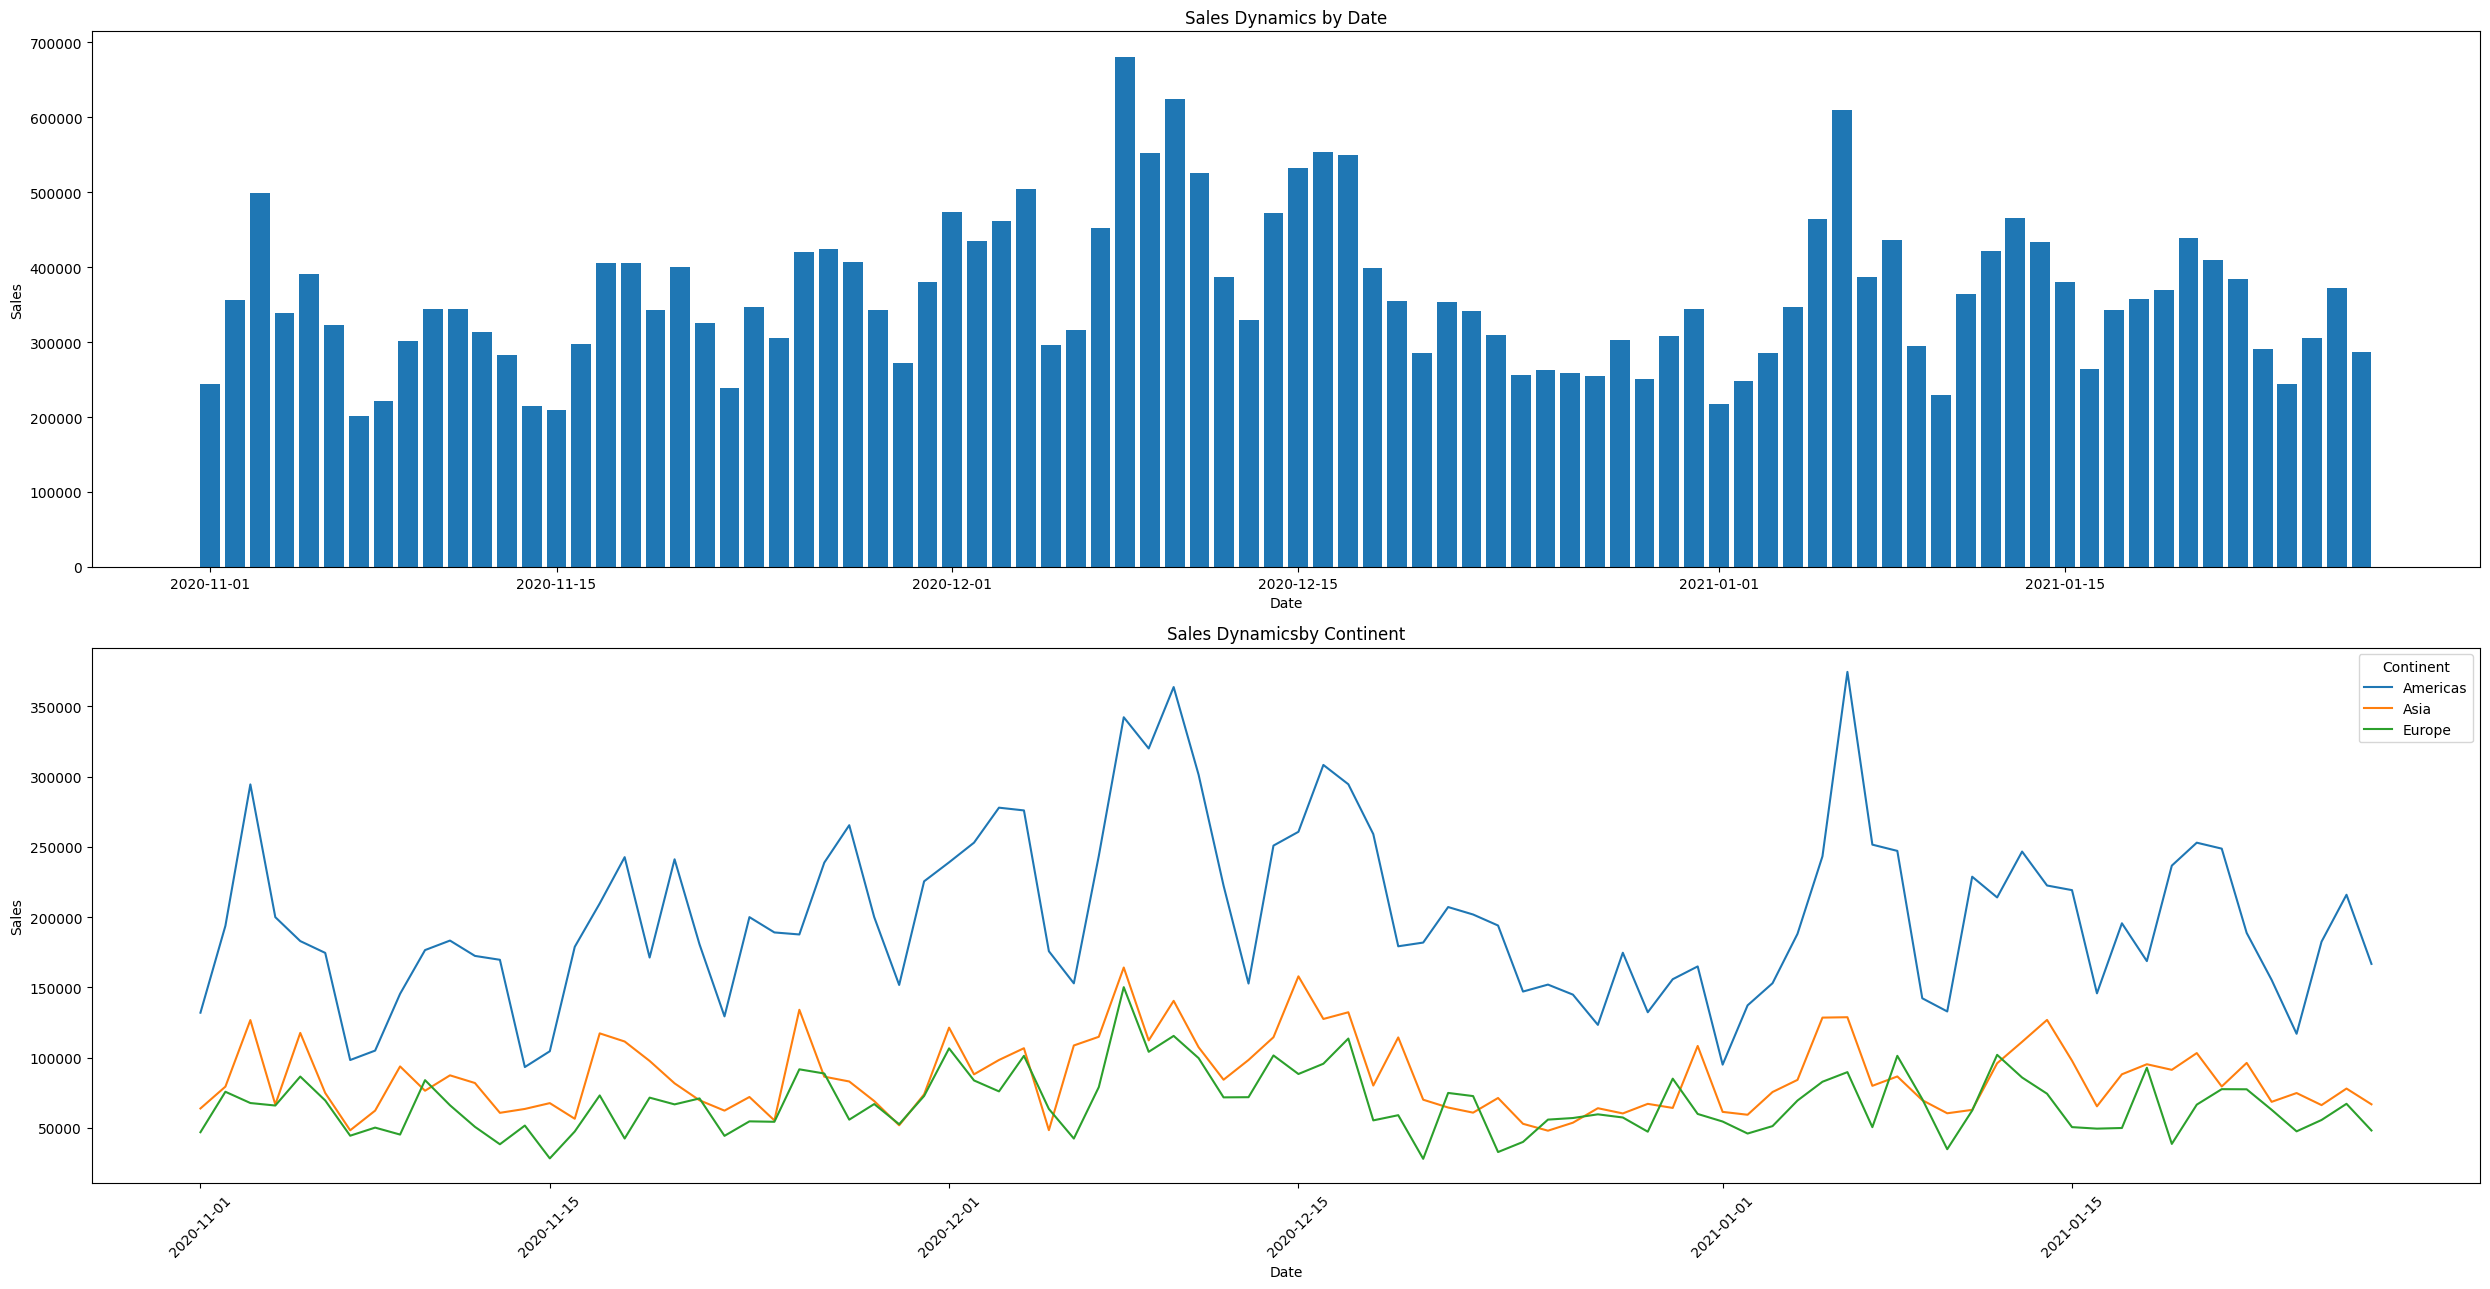

In [ ]:
sales_by_date = df.groupby("order_date")["price"].sum().reset_index()

fig, ax = plt.subplots(2, 1, figsize=(25, 13))
ax[0].bar(sales_by_date["order_date"], sales_by_date["price"])
ax[0].set_title("Sales Dynamics by Date")
ax[0].set_xlabel("Date")
ax[0].set_ylabel("Sales")

continent1 = df[df["continent"].isin(["Americas", "Europe", "Asia"])]
sales_by_date_continent = continent1.groupby(["order_date", "continent"])["price"].sum().reset_index()

continents = sales_by_date_continent["continent"].unique()

for cont in sales_by_date_continent["continent"].unique():
    data = sales_by_date_continent[sales_by_date_continent["continent"] == cont]
    ax[1].plot(data["order_date"], data["price"], label=cont)

ax[1].set_title("Sales Dynamicsby Continent")
ax[1].set_xlabel("Date")
ax[1].set_ylabel("Sales")
ax[1].legend(title="Continent")
ax[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

#Статистичний аналіз відмінностей між групами.
* Аналіз кількості сесій за різними каналами трафіку. Чи є статистично значущі відмінності між групами? **Статистично значущої різниці немає, p-value більше 0.05.**
* Чи відрізняється статистично доля сесій з органічним трафіком у Європі та Америці? **Статистично значущої різниці немає, p-value більше 0.05.**


In [ ]:
from scipy.stats import kruskal
from statsmodels.stats.proportion import proportions_ztest
pivot_channel = df.groupby("channel")["ga_session_id"].count()
print(pivot_channel)
channels = pivot_channel.index
session_counts = [df[df["channel"] == channel]["ga_session_id"] for channel in channels]
session_counts_kruskal = [df[df["channel"] == channel]["ga_session_id"] for channel in pivot_channel.index]
stat, p_value = kruskal(*session_counts_kruskal)

print(f"Kruskal-Wallis H-statistic: {stat}")
print(f"Kruskal-Wallis p-value: {p_value}")

usa_eu = df[df["continent"].isin(["Americas", "Europe"]) & (df["channel"] == "Organic Search")]
total_sessions = df[df["continent"].isin(["Americas", "Europe"])]["ga_session_id"].count()
eu_sessions = df[(df["continent"] == "Europe") & (df["channel"] == "Organic Search")]["ga_session_id"].count()
us_sessions = df[(df["continent"] == "Americas") & (df["channel"] == "Organic Search")]["ga_session_id"].count()

eu_percentage = eu_sessions / total_sessions
us_percentage = us_sessions / total_sessions

print(f"\n\nEurope: {eu_percentage*100}% session with organic channel")
print(f"Americas: {us_percentage*100}% session with organic channel")

count = [eu_sessions, us_sessions]
nobs = [df[df["continent"] == "Europe"]["ga_session_id"].count(), df[df["continent"] == "Americas"]["ga_session_id"].count()]

stat, p_value = proportions_ztest(count, nobs)

print(f"Z-stat: {stat}")
print(f"P-value: {p_value}")



channel
Direct             7800
Organic Search    11921
Paid Search        9042
Social Search      2716
Undefined          2059
Name: ga_session_id, dtype: Int64
Kruskal-Wallis H-statistic: 6.964735726534855
Kruskal-Wallis p-value: 0.13776355738680546


Europe: 9.019102119771096% session with organic channel
Americas: 26.339969372128635% session with organic channel
Z-stat: 0.7388657778581375
P-value: 0.45998850476985065


#Статистичний аналіз взаємозв’язків.
* Кореляція між продажами на різних континентах. Топ-3 континенти. Статистична значущість взаємозв’язків. **P-value < 0.05, це говорить, що є статистично значущий звʼязок. Коефіцієнт кореляції показує що, всі континенти корелюють між собою (помірно позитивна кореляція)**
* Кореляція між продажами за топ-5 категоріями товарів. Статистична значущість взаємозв’язків.**P-value < 0.05, це говорить, що є статистично значущий звʼязок. Коефіцієнт кореляції показує що, майже всі категорії корелюють між собою (помірно позитивна кореляція)**

Будемо використовувати метод Анова, та коефіцієнт кореляції Спирмена

/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 33538.
  res = hypotest_fun_out(*samples, **kwds)


Normaltest p-value: 0.0
Shapiro p-value: 5.379096120538938e-118


Continent ANOVA F-statistic: 284.8636333983241
Continent ANOVA p-value: 2.411328976331836e-66


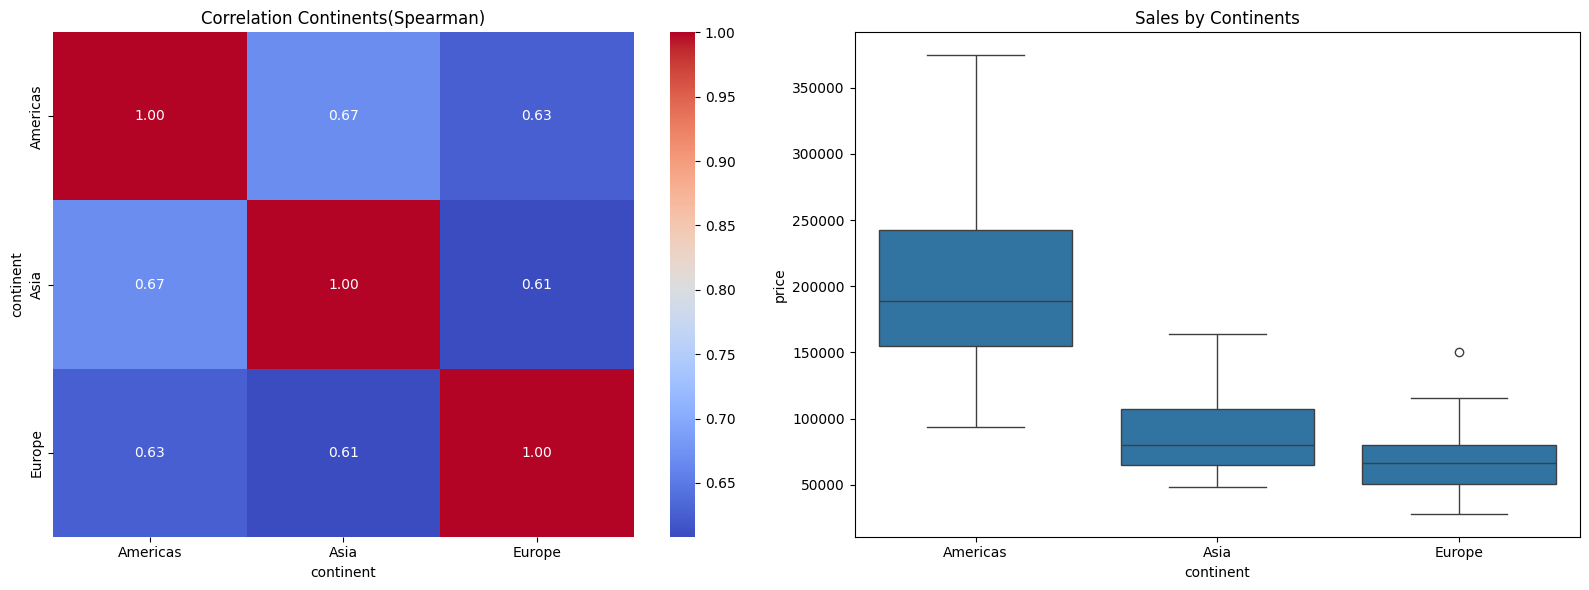

Category ANOVA F-statistic: 137.21681751409747
Category ANOVA p-value: 9.891825037136092e-76


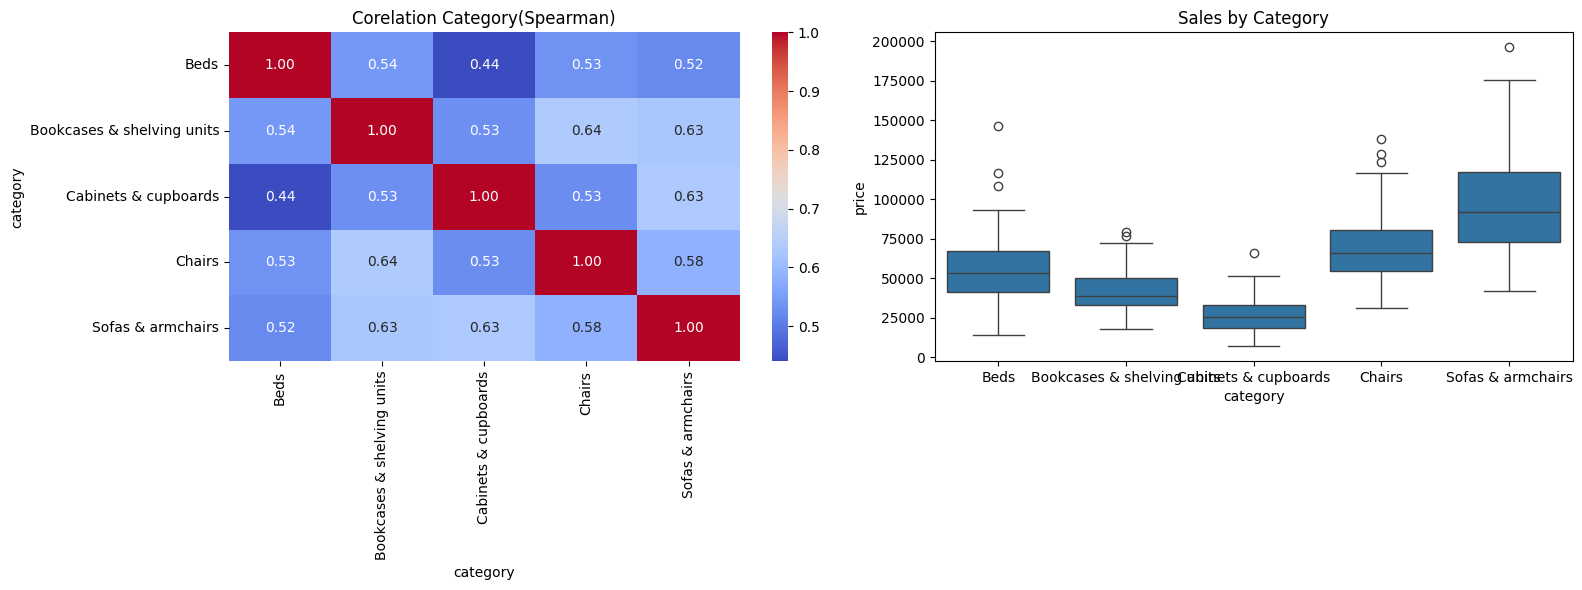

In [ ]:
from scipy.stats import normaltest, shapiro, spearmanr, f_oneway
pd.options.mode.chained_assignment = None
q1 = np.percentile(df["price"], 25)
q3 = np.percentile(df["price"], 75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
outliers = [x for x in df["price"] if x < lower or x > upper]
delete_outliers = [x for x in df["price"] if x >= lower or x <= upper]

_, p_value_normaltest = normaltest(df["price"])
_, p_value_shapiro = shapiro(df["price"])
print("Normaltest p-value:", p_value_normaltest)
print("Shapiro p-value:", p_value_shapiro)

top_continents = df.groupby("continent")["price"].sum().nlargest(3).index
filtered_continents = df[df["continent"].isin(top_continents)]
pivot_table_continent = pd.pivot_table(filtered_continents,index="order_date", values="price", columns="continent", aggfunc="sum", fill_value=0)
pivot_table_continent["Total"] = pivot_table_continent.sum(axis=1)
pivot_table_continent = pivot_table_continent.sort_values("Total", ascending=False).drop(columns="Total")
anova = f_oneway(
    pivot_table_continent["Europe"],
    pivot_table_continent["Asia"],
    pivot_table_continent["Americas"]
)
print("\n\nContinent ANOVA F-statistic:", anova.statistic)
print("Continent ANOVA p-value:", anova.pvalue)
corr_matrix = pivot_table_continent.corr(method="spearman")

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", ax=ax[0])
ax[0].set_title("Correlation Continents(Spearman)")

filtered_continents["order_date"] = pd.to_datetime(filtered_continents["order_date"])
daily = filtered_continents.groupby(["order_date", "continent"])["price"].sum().reset_index()

sns.boxplot(data=daily, x="continent", y="price", ax=ax[1])
ax[1].set_title("Sales by Continents")
plt.tight_layout()
plt.show()


top_category = df.groupby("category")["price"].sum().nlargest(5).index
filtered_category = df[df["category"].isin(top_category)]
pivot_table_category = pd.pivot_table(filtered_category,index="order_date", values="price", columns="category", aggfunc="sum", fill_value=0)
pivot_table_category["Total"] = pivot_table_category.sum(axis=1)
pivot_table_category = pivot_table_category.sort_values("Total", ascending=False).drop(columns="Total")
anova1 = f_oneway(
    pivot_table_category["Beds"],
    pivot_table_category["Bookcases & shelving units"],
    pivot_table_category["Cabinets & cupboards"],
    pivot_table_category["Chairs"],
    pivot_table_category["Sofas & armchairs"]
)
print("Category ANOVA F-statistic:", anova1.statistic)
print("Category ANOVA p-value:", anova1.pvalue)

corr_matrix_category = pivot_table_category.corr(method="spearman")
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(corr_matrix_category, annot=True, cmap="coolwarm", fmt=".2f", ax=ax[0])
ax[0].set_title("Corelation Category(Spearman)")

filtered_category["order_date"] = pd.to_datetime(filtered_category["order_date"])
daily = filtered_category.groupby(["order_date", "category"])["price"].sum().reset_index()

sns.boxplot(data=daily, x="category", y="price", ax=ax[1])
ax[1].set_title("Sales by Category")
plt.tight_layout()
plt.show()


 **Кількість сесій та загальні продажі за кожну дату. Взаємозв’язок між цими метриками. Кореляція та P-value. Лінійна регресія.**
### Висновок:
* Кореляція між кількістю сесій і загальними продажами висока:

  Коефіцієнт кореляції (Spearman) ≈ 0.79 — це сильний позитивний зв'язок.

  Значення p-value ≈ 9.76e-29 означає, що зв'язок є статистично значущим (ймовірність випадковості майже нуль).

* Результати нормальності розподілу:

  Тест нормальності для total_sales дав p-value ≈ 0.021.

  Це вказує на те, що розподіл не зовсім нормальний (можливо, є перекоси або викиди в даних).

* Результати моделювання (Ridge регресія):

  Зв'язок між сесіями і продажами підтвердився моделлю.

  R² ≈ 0.69 — модель пояснює близько 69% варіації у продажах на основі кількості сесій.

  MAE (mean absolute error) ≈ 47 554 — середня помилка прогнозу в абсолютному значенні.

* Оптимальний параметр регуляризації (альфа):

  Підібрано через RidgeCV: alpha = 1000.

  Це допомогло уникнути переобучення і трохи стабілізувало модель.

* Загальний висновок: Кількість сесій має сильний і статистично значущий вплив на обсяг продажів.

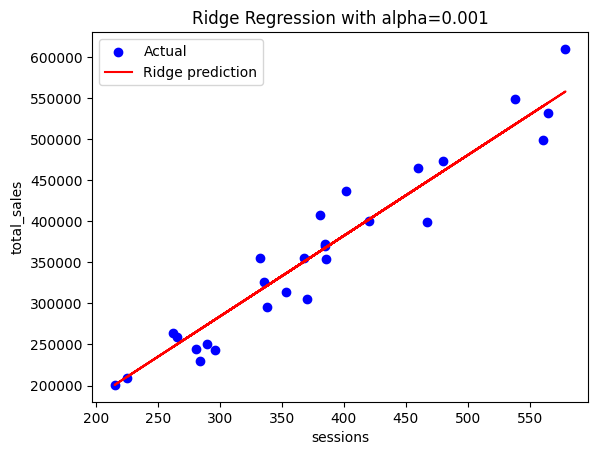

               Model  R2 Score           MAE
0  Linear Regression  0.927887  23539.398516
1   Ridge Regression  0.927887  23539.398527
2   Lasso Regression  0.927887  23539.398523


Normaltest for total_sales 0.007155898618108501
P-value by Spearman:  1.346332900826623e-45
Type of corelation:  0.9642422533124876
Optimal alpha for Ridge model: 0.001


Mean absolute error of Linear Regression:  23539.39852275788
R2 of Linear Regression:  0.9278867914109167


In [ ]:
from scipy.stats import normaltest, spearmanr
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
group_by_date = df.groupby("order_date").agg(sessions=("ga_session_id", "nunique"),total_sales=("price", "sum")).reset_index()
q1 = np.percentile(group_by_date["total_sales"], 25)
q3 = np.percentile(group_by_date["total_sales"], 75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
outliers = [x for x in group_by_date["total_sales"] if x < lower or x > upper]

_, p_value_normaltest = normaltest(group_by_date["total_sales"])
_, p_value = spearmanr(group_by_date["total_sales"], group_by_date["sessions"])
n_corr = group_by_date["total_sales"].corr(group_by_date["sessions"])

X = group_by_date[["sessions"]]
y = group_by_date["total_sales"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 2025)
ridge = Ridge(alpha = 1000)
ridge.fit(X_train, y_train)
y_pred = ridge.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
possible_alpha = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
ridge_cv = RidgeCV(alphas=possible_alpha, scoring="r2")
ridge_cv.fit(X_train, y_train)


plt.scatter(X_test, y_test, label="Actual", color="blue")
plt.plot(X_test, ridge_cv.predict(X_test), label="Ridge prediction", color="red")
plt.xlabel("sessions")
plt.ylabel("total_sales")
plt.title(f"Ridge Regression with alpha={ridge_cv.alpha_}")
plt.legend()
plt.show()

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=ridge_cv.alpha_),
    "Lasso Regression": Lasso(alpha=0.01)
}
results = {
    "Model": [],
    "R2 Score": [],
    "MAE": []
}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    results["Model"].append(name)
    results["R2 Score"].append(r2)
    results["MAE"].append(mae)

import pandas as pd
results_df = pd.DataFrame(results)
print(results_df)


print("\n\nNormaltest for total_sales",p_value_normaltest)
print("P-value by Spearman: ", p_value )
print("Type of corelation: ", n_corr)
print(f"Optimal alpha for Ridge model: {ridge_cv.alpha_}")
print("\n\nMean absolute error of Linear Regression: ", mae)
print("R2 of Linear Regression: ", r2)

**Додамо до лінійної регресії більше фіч ("device, browser, registered_session"):**
### Результат:
* Після додавання нових фіч (тип пристрою, браузер, статус реєстрації) R² значно зріс до 0.94, а MAE зменшився до 21 702.

 Це свідчить про те, що нові ознаки допомогли краще пояснити варіацію в продажах.
* Зареєстровані користувачі (registered_sessions) мають найсильніший позитивний вплив на загальний обсяг продажів.

 Браузер Edge має найсильніший негативний вплив — можливо, користувачі з Edge менш охоче купують або мають інші патерни поведінки.

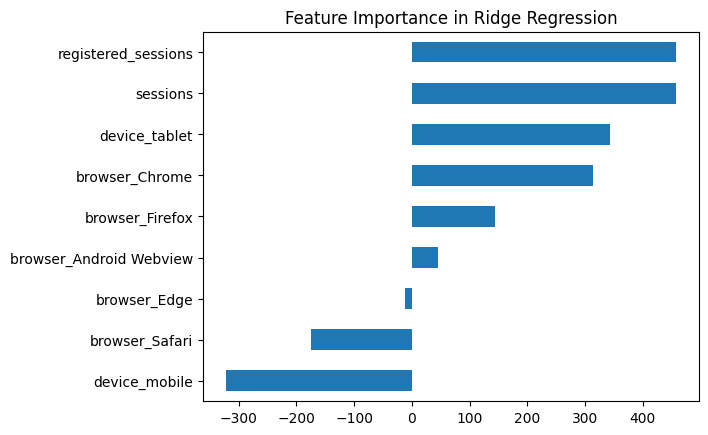

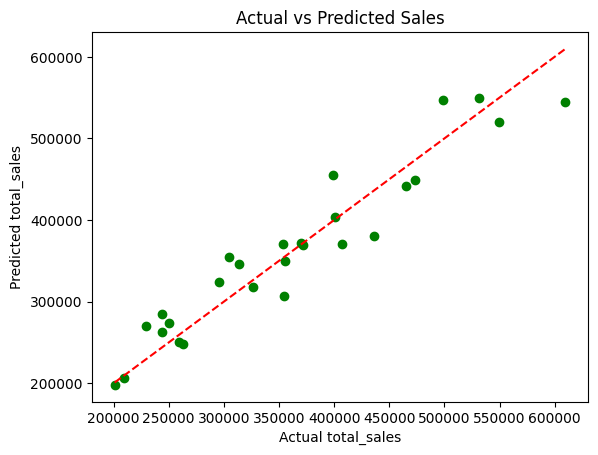

0.9115866347165466
26072.622251928395
   index                  Feature  Coefficient
0      1      registered_sessions   458.213830
1      0                 sessions   458.213830
2      3            device_tablet   343.897729
3      5           browser_Chrome   313.750357
4      7          browser_Firefox   144.454649
5      4  browser_Android Webview    46.048343
6      6             browser_Edge   -11.175264
7      8           browser_Safari  -174.139539
8      2            device_mobile  -322.766619


In [ ]:

df_encoded = pd.get_dummies(df, columns=["device", "browser"], drop_first=True)

agg_dict = {
    'ga_session_id': 'nunique',
    'price': 'sum',
    'name': 'count',
}

for col in df_encoded.columns:
    if col.startswith('device_') or col.startswith('browser_'):
        agg_dict[col] = 'sum'

group_by_date = df_encoded.groupby("order_date").agg(agg_dict).reset_index()
group_by_date = group_by_date.rename(columns={
    "ga_session_id": "sessions",
    "price": "total_sales",
    "name": "registered_sessions"
})

X = group_by_date[["sessions", "registered_sessions"] + list(df_encoded.columns[df_encoded.columns.str.startswith('device_') | df_encoded.columns.str.startswith('browser_')])]
y = group_by_date["total_sales"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 2025)
ridge = Ridge(alpha = 1000)
ridge.fit(X_train, y_train)
y_pred = ridge.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
possible_alpha = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
ridge_cv = RidgeCV(alphas=possible_alpha, scoring="r2")
ridge_cv.fit(X_train, y_train)

importance = pd.Series(ridge_cv.coef_, index=X.columns)
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance in Ridge Regression")
plt.show()

plt.scatter(y_test, ridge_cv.predict(X_test), color="green")
plt.xlabel("Actual total_sales")
plt.ylabel("Predicted total_sales")
plt.title("Actual vs Predicted Sales")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')  # ідеальна лінія
plt.show()

print(r2)
print(mae)

features = ["sessions", "registered_sessions"] + list(df_encoded.columns[df_encoded.columns.str.startswith('device_') | df_encoded.columns.str.startswith('browser_')])
coefficients = ridge.coef_
coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": coefficients
})
coef_df = coef_df.sort_values(by="Coefficient", ascending=False).reset_index()
print(coef_df)


## Посилання на Dashboard:
https://public.tableau.com/app/profile/.38337362/viz/PortfolioProject_17459239948350/Dashboard1